# AI Usage & Impact: Students and Professionals

**Objective:** Explore AI adoption, usage patterns, perceived productivity, time savings, satisfaction, and recommendation intent across students and professionals.

> **Data note:** The source is a 300-row self-reported survey dataset. Results below describe associations in this sample; they do not establish causation.


## 1. Setup and data loading

This notebook standardizes common formatting inconsistencies (for example, `Chat GPT` vs. `ChatGPT`, currency symbols, and `hrs` suffixes) while retaining every source row for analysis.

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 50)


In [2]:
import kagglehub
path = kagglehub.dataset_download("eishatuzzuhra/ai-usage-and-impact-on-students-and-professionals")

In [3]:
import os
import pandas as pd
import kagglehub

# Download the dataset
path = kagglehub.dataset_download("eishatuzzuhra/ai-usage-and-impact-on-students-and-professionals")

# Find the CSV file inside the downloaded directory
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

if csv_files:
    csv_path = os.path.join(path, csv_files[0])
    raw = pd.read_csv(csv_path)
    print(f"Loaded: {csv_files[0]}")
    raw.head()
else:
    print("No CSV file found in the downloaded directory.")

Loaded: AI_Usage_and_Impact_on_Students_and_Professionals.csv


## 2. Data quality and cleaning

### Cleaning decisions
- Parse numeric-like fields that contain units or currency symbols.
- Harmonize categorical labels for gender, education, and AI tools.
- Keep duplicate `User_ID` rows because the file does not indicate which record, if any, is erroneous.
- Leave missing entries as missing rather than imputing subjective survey responses.

In [4]:
def clean_text(x):
    if pd.isna(x):
        return np.nan
    return str(x).strip()

def parse_num(x):
    if pd.isna(x):
        return np.nan
    match = re.search(r'-?\d+(?:\.\d+)?', str(x).replace(',', '').strip())
    return float(match.group()) if match else np.nan

def normalize_gender(x):
    x = clean_text(x)
    if pd.isna(x):
        return np.nan
    return {
        'm': 'Male', 'male': 'Male',
        'f': 'Female', 'female': 'Female',
        'other': 'Other', 'non-binary': 'Non-binary'
    }.get(x.lower(), x.title())

def normalize_education(x):
    x = clean_text(x)
    if pd.isna(x):
        return np.nan
    key = x.lower().replace('.', '').strip()
    mapping = {
        'undergrad': 'Undergraduate', 'undergraduate': 'Undergraduate',
        'bachelors': "Bachelor's", 'bachelor': "Bachelor's", 'babsc': "Bachelor's",
        'masters': "Master's", 'master': "Master's",
        'phd': 'PhD', 'high school': 'High School', 'highschool': 'High School',
        'diploma': 'Diploma'
    }
    return mapping.get(key, x)

def normalize_tool(x):
    x = clean_text(x)
    if pd.isna(x):
        return np.nan
    key = x.lower().replace(' ', '')
    mapping = {
        'chatgpt': 'ChatGPT', 'copilot': 'Microsoft Copilot',
        'microsoftcopilot': 'Microsoft Copilot', 'googlegemini': 'Google Gemini',
        'perplexityai': 'Perplexity AI', 'metaai': 'Meta AI',
        'deepseek': 'DeepSeek', 'claude': 'Claude', 'grammarly': 'Grammarly'
    }
    return mapping.get(key, x)

df = raw.copy()
for col in ['Age', 'Monthly_Income', 'AI_Usage_Hours_Per_Day', 'Monthly_AI_Cost',
            'Time_Saved_Hours_Per_Week', 'Work_or_Study_Hours_Per_Day']:
    df[col] = df[col].map(parse_num)

df['Gender'] = df['Gender'].map(normalize_gender)
df['Education_Level'] = df['Education_Level'].map(normalize_education)
df['AI_Tool'] = df['AI_Tool'].map(normalize_tool)
for col in ['Country', 'User_Type', 'Profession', 'AI_Purpose', 'Tasks_Performed', 'Would_Recommend']:
    df[col] = df[col].map(clean_text)

print(f'Rows: {len(df):,}')
print(f'Unique User_IDs: {df.User_ID.nunique():,}')
print(f'Duplicate User_ID rows beyond first occurrence: {df.User_ID.duplicated().sum():,}')
print(f'Total missing cells after cleaning: {df.isna().sum().sum():,}')
df.isna().sum().sort_values(ascending=False).to_frame('missing_values')

Rows: 300
Unique User_IDs: 288
Duplicate User_ID rows beyond first occurrence: 12
Total missing cells after cleaning: 204


,missing_values
Age,23
Tasks_Performed,18
Productivity_Score,16
Profession,15
Accuracy_Rating,15
AI_Purpose,13
Education_Level,13
Monthly_AI_Cost,12
AI_Tool,11
Time_Saved_Hours_Per_Week,10


## 3. Snapshot of the sample

In [5]:
kpis = pd.Series({
    'Respondent records': len(df),
    'Students': (df['User_Type'] == 'Student').sum(),
    'Professionals': (df['User_Type'] == 'Professional').sum(),
    'Mean AI use (hours/day)': df['AI_Usage_Hours_Per_Day'].mean(),
    'Mean time saved (hours/week)': df['Time_Saved_Hours_Per_Week'].mean(),
    'Mean productivity score': df['Productivity_Score'].mean(),
    'Mean satisfaction score': df['Satisfaction_Score'].mean(),
    'Would recommend AI (%)': 100 * (df['Would_Recommend'] == 'Yes').mean()
})
kpis.round(2).to_frame('value')

,value
Respondent records,300.00
Students,158.00
Professionals,142.00
Mean AI use (hours/day),2.95
Mean time saved (hours/week),5.85
Mean productivity score,5.23
Mean satisfaction score,6.15
Would recommend AI (%),59.33


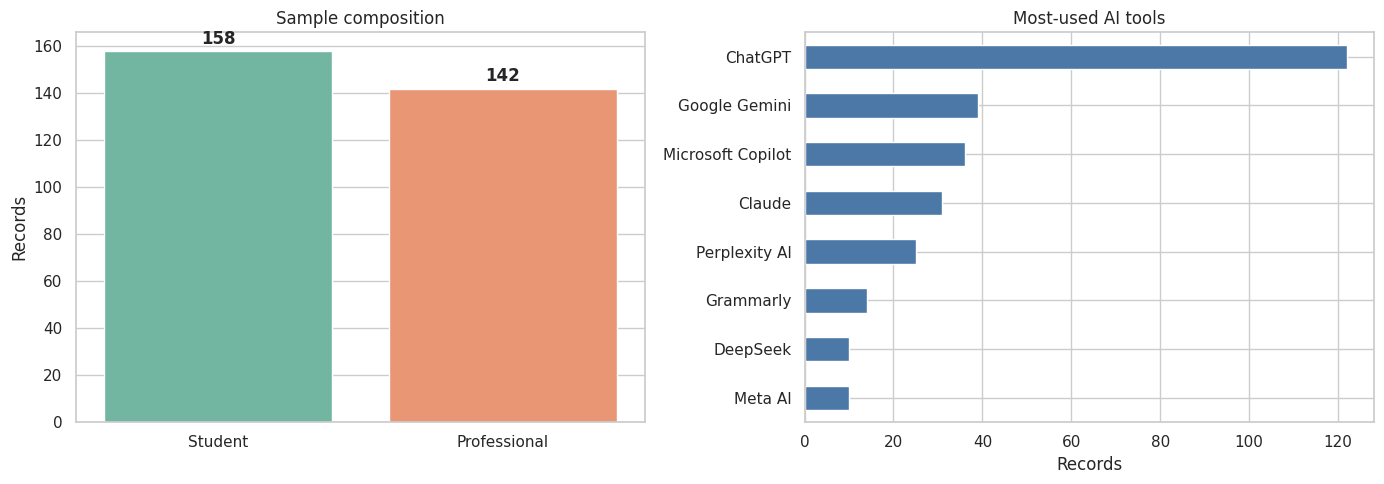

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

user_counts = df['User_Type'].value_counts()
sns.barplot(x=user_counts.index, y=user_counts.values, ax=axes[0], hue=user_counts.index, palette='Set2', legend=False)
axes[0].set(title='Sample composition', xlabel='', ylabel='Records')
for i, v in enumerate(user_counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

tool_counts = df['AI_Tool'].value_counts().head(8).sort_values()
tool_counts.plot(kind='barh', ax=axes[1], color='#4C78A8')
axes[1].set(title='Most-used AI tools', xlabel='Records', ylabel='')
plt.tight_layout()
plt.show()

## 4. AI usage by purpose and user type

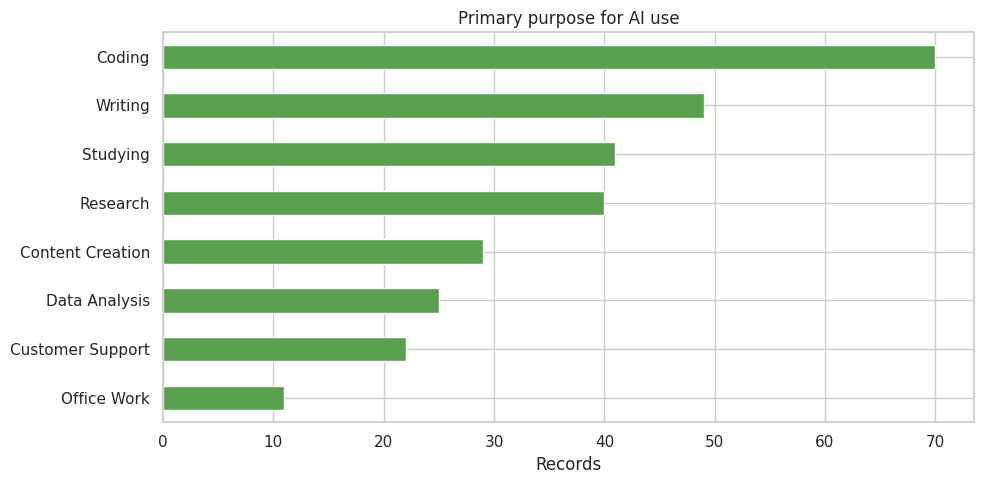

,records,avg_usage_hours_day,avg_time_saved_week,avg_productivity,avg_satisfaction,recommend_yes_pct
User_Type,,,,,,
Professional,142,2.86,5.56,5.28,6.08,57.75
Student,158,3.04,6.10,5.19,6.20,60.76


In [7]:
purpose_counts = df['AI_Purpose'].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(10, 5))
purpose_counts.plot(kind='barh', color='#59A14F', ax=ax)
ax.set(title='Primary purpose for AI use', xlabel='Records', ylabel='')
plt.tight_layout()
plt.show()

usage_by_type = (df.groupby('User_Type')
                   .agg(records=('User_ID', 'size'),
                        avg_usage_hours_day=('AI_Usage_Hours_Per_Day', 'mean'),
                        avg_time_saved_week=('Time_Saved_Hours_Per_Week', 'mean'),
                        avg_productivity=('Productivity_Score', 'mean'),
                        avg_satisfaction=('Satisfaction_Score', 'mean'),
                        recommend_yes_pct=('Would_Recommend', lambda s: 100 * (s == 'Yes').mean()))
                   .round(2))
usage_by_type

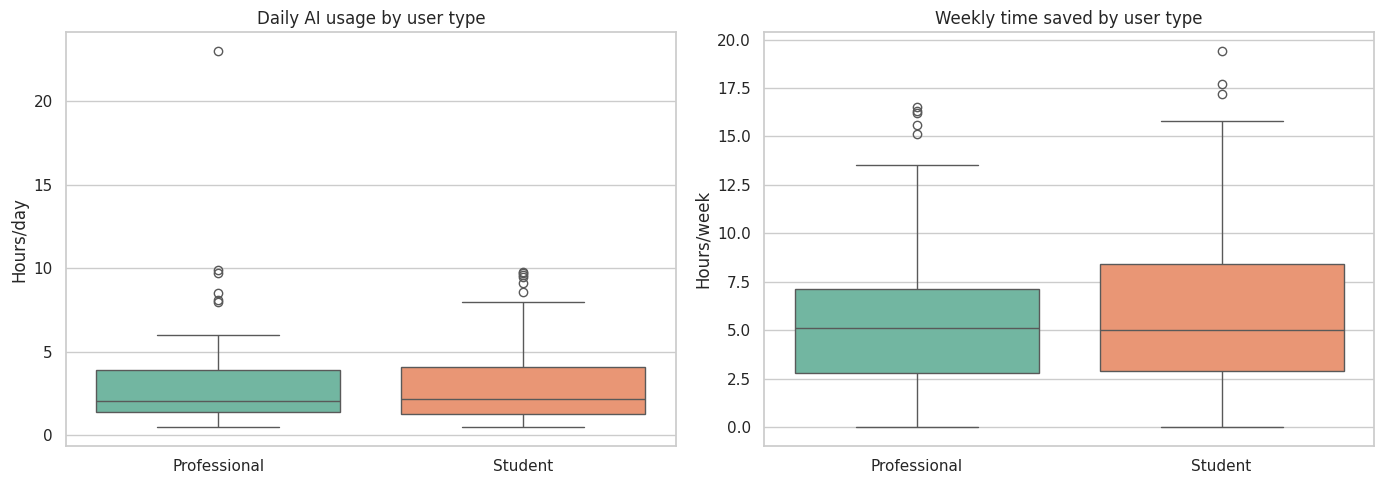

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1
sns.boxplot(
    data=df, 
    x='User_Type', 
    y='AI_Usage_Hours_Per_Day', 
    hue='User_Type', 
    palette='Set2', 
    legend=False, 
    ax=axes[0]
)
axes[0].set(title='Daily AI usage by user type', xlabel='', ylabel='Hours/day')

# Plot 2
sns.boxplot(
    data=df, 
    x='User_Type', 
    y='Time_Saved_Hours_Per_Week', 
    hue='User_Type', 
    palette='Set2', 
    legend=False, 
    ax=axes[1]
)
axes[1].set(title='Weekly time saved by user type', xlabel='', ylabel='Hours/week')

plt.tight_layout()
plt.show()

## 5. Perceived impact

The scatter plot below shows the relationship between reported AI-use intensity and reported weekly time savings. The fitted line is descriptive only.

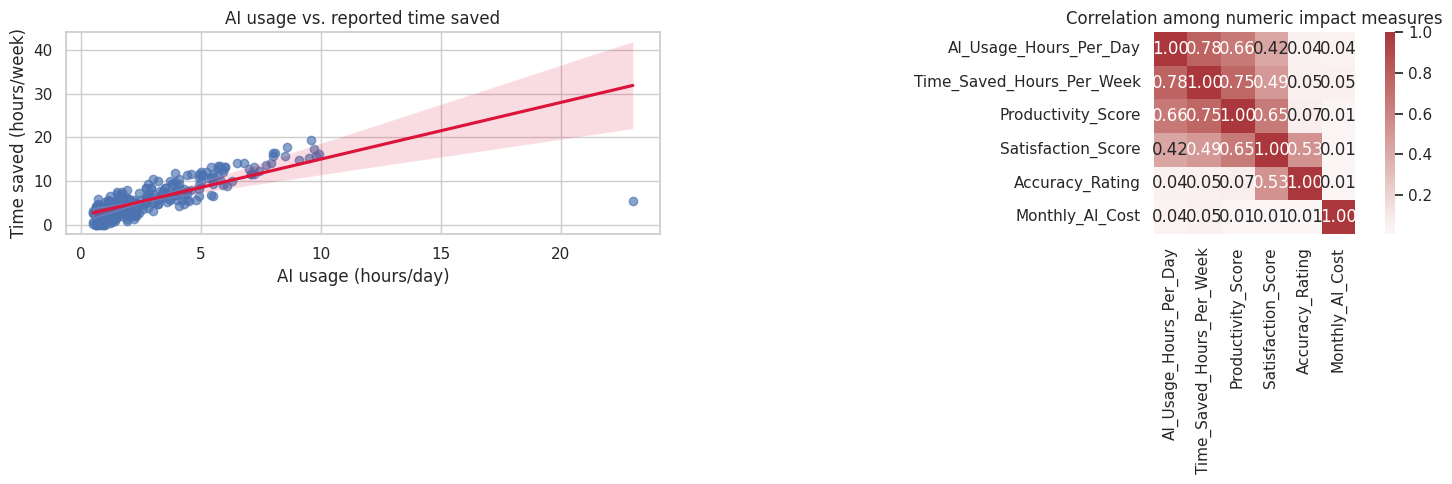

,AI_Usage_Hours_Per_Day,Time_Saved_Hours_Per_Week,Productivity_Score,Satisfaction_Score,Accuracy_Rating,Monthly_AI_Cost
AI_Usage_Hours_Per_Day,1.00,0.78,0.66,0.42,0.04,0.04
Time_Saved_Hours_Per_Week,0.78,1.00,0.75,0.49,0.05,0.05
Productivity_Score,0.66,0.75,1.00,0.65,0.07,0.01
Satisfaction_Score,0.42,0.49,0.65,1.00,0.53,0.01
Accuracy_Rating,0.04,0.05,0.07,0.53,1.00,0.01
Monthly_AI_Cost,0.04,0.05,0.01,0.01,0.01,1.00


In [9]:
impact = df[['AI_Usage_Hours_Per_Day', 'Time_Saved_Hours_Per_Week', 'Productivity_Score',
             'Satisfaction_Score', 'Accuracy_Rating', 'Monthly_AI_Cost']]
corr = impact.corr(numeric_only=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.regplot(data=df, x='AI_Usage_Hours_Per_Day', y='Time_Saved_Hours_Per_Week',
            scatter_kws={'alpha': 0.65}, line_kws={'color': 'crimson'}, ax=axes[0])
axes[0].set(title='AI usage vs. reported time saved', xlabel='AI usage (hours/day)', ylabel='Time saved (hours/week)')

sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0, ax=axes[1], square=True)
axes[1].set_title('Correlation among numeric impact measures')
plt.tight_layout()
plt.show()

corr.round(2)

## 6. Recommendation intent and satisfaction

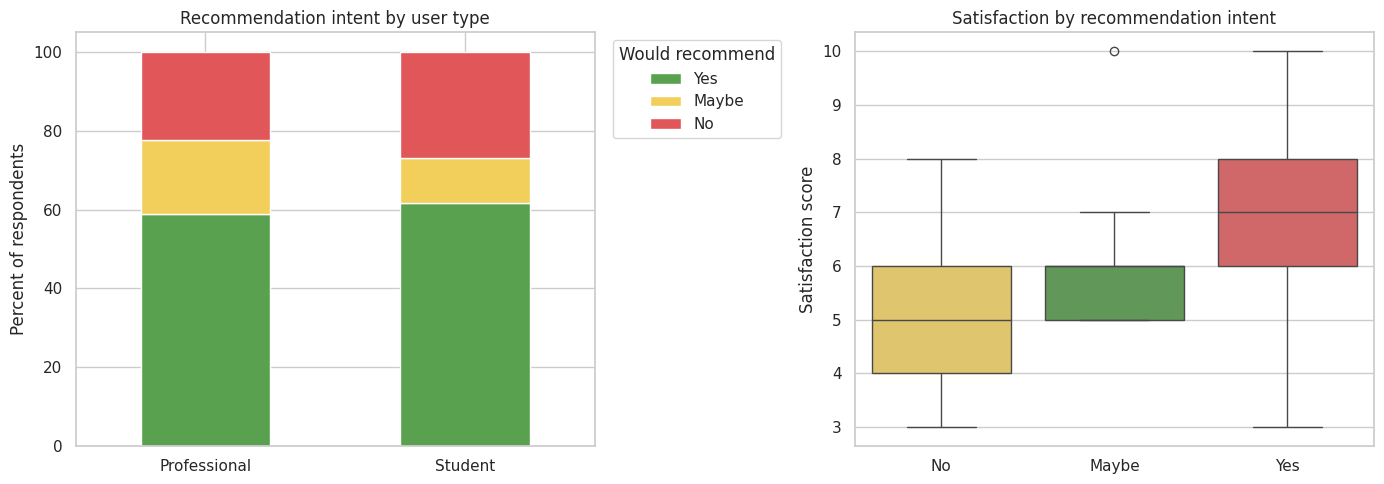

Would_Recommend,Yes,Maybe,No
User_Type,,,
Professional,59.0,18.7,22.3
Student,61.5,11.5,26.9


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rec = pd.crosstab(df['User_Type'], df['Would_Recommend'], normalize='index').mul(100)
rec = rec.reindex(columns=['Yes', 'Maybe', 'No'])
rec.plot(kind='bar', stacked=True, color=['#59A14F', '#F2CF5B', '#E15759'], ax=axes[0])
axes[0].set(title='Recommendation intent by user type', xlabel='', ylabel='Percent of respondents')
axes[0].legend(title='Would recommend', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[0].tick_params(axis='x', rotation=0)

sns.boxplot(
    data=df, 
    x='Would_Recommend', 
    y='Satisfaction_Score', 
    hue='Would_Recommend',
    order=['No', 'Maybe', 'Yes'], 
    palette=['#E15759', '#F2CF5B', '#59A14F'], 
    legend=False,
    ax=axes[1]
)
axes[1].set(title='Satisfaction by recommendation intent', xlabel='', ylabel='Satisfaction score')
plt.tight_layout()
plt.show()

rec.round(1)

## 7. Key findings

Based on the cleaned dataset:

- **ChatGPT is the dominant tool** in the sample, followed by Google Gemini and Microsoft Copilot.
- **Coding is the leading use case**, with writing, studying, and research also prominent.
- Students report slightly higher average daily AI use and weekly time savings than professionals in this sample.
- Reported AI use is strongly associated with reported time saved and productivity. This is an **association**, not evidence that AI use alone caused the outcomes.
- Satisfaction and accuracy ratings are positively associated, and respondents who would recommend AI tend to show higher satisfaction.
- Monthly AI cost has little linear association with the reported productivity and time-saved measures here.

### Caveats
- Survey responses are self-reported and may include recall or selection bias.
- 12 `User_ID` values appear more than once; no deduplication was applied without a confirmed respondent-level key.
- Several fields have missing values, so summary calculations use available observations per measure.


## 8. Export cleaned data

The following cell writes the cleaned analysis-ready dataset to a CSV file.

In [11]:
OUTPUT = 'cleaned_ai_usage_impact.csv'
df.to_csv(OUTPUT, index=False)
print(f'Saved: {OUTPUT}')

Saved: cleaned_ai_usage_impact.csv
